In [10]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Reproducibility: seeds Python, NumPy and TensorFlow at once
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Mixed precision: float16 compute + float32 weights → uses CUDA Tensor Cores
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [11]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [12]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

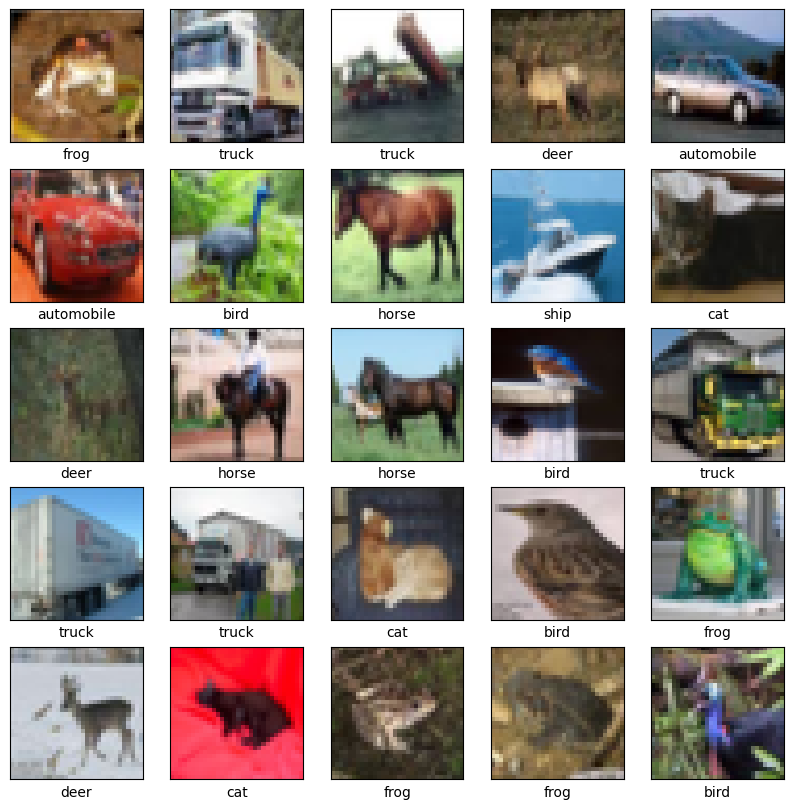

In [13]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [14]:
inputs = layers.Input(shape=(32, 32, 3))

x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomTranslation(0.1, 0.1, fill_mode="reflect")(x)

# Stem
x = layers.Conv2D(16, 3, padding='same', use_bias=False)(x)

# Residual block (pre-activation / v2 style)
def block(x, filters, stride=1):
    shortcut = x

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False)(shortcut)

    x = layers.Add()([x, shortcut])
    return x

# Stages
x = block(x, 16, stride=1)
x = block(x, 16, stride=2)

x = block(x, 32, stride=1)
x = block(x, 32, stride=2)

x = block(x, 64, stride=1)

# Head
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.1)(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, dtype='float32')(x)  # float32 required for mixed precision stability

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 32, 32, 3) │          0 │ input_layer_1[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 32, 32, 3) │          0 │ random_flip_1[0]… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │        432 │ random_translati… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │      2,304 │ re_lu_11[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │      2,304 │ re_lu_12[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32, 32,    │          0 │ conv2d_17[0][0],  │
│                     │ 16)               │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ add_5[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 16, 16,    │      2,304 │ re_lu_13[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │      2,304 │ re_lu_14[0][0]  

 Total params: 103,034 (402.48 KB)

 Trainable params: 102,362 (399.85 KB)

 Non-trainable params: 672 (2.62 KB)

In [16]:
BATCH_SIZE = 256
EPOCHS = 100
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    .cache()
    .shuffle(50000, seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

steps_per_epoch = 50000 // BATCH_SIZE
total_steps = steps_per_epoch * EPOCHS

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.1,
    decay_steps=total_steps
)

optimizer = tf.keras.optimizers.SGD(
    learning_rate=lr_schedule,
    momentum=0.9,
    nesterov=True
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds)

Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4414 - loss: 1.5155 - val_accuracy: 0.3716 - val_loss: 1.9917
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6139 - loss: 1.0716 - val_accuracy: 0.4671 - val_loss: 2.0797
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6771 - loss: 0.9063 - val_accuracy: 0.6311 - val_loss: 1.1162
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7124 - loss: 0.8089 - val_accuracy: 0.5965 - val_loss: 1.2494
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7399 - loss: 0.7417 - val_accuracy: 0.5682 - val_loss: 1.3773
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7577 - loss: 0.6885 - val_accuracy: 0.7371 - val_loss: 0.7796
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7695 - loss: 0.6595 - val_accuracy: 0.6194 - val_loss: 1.3049
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7810 - loss: 0.6274 - 

In [17]:
test_loss = model.evaluate(test_images,  test_labels, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.8750 - loss: 0.3969


In [18]:
test_loss

[0.3969317376613617, 0.875]

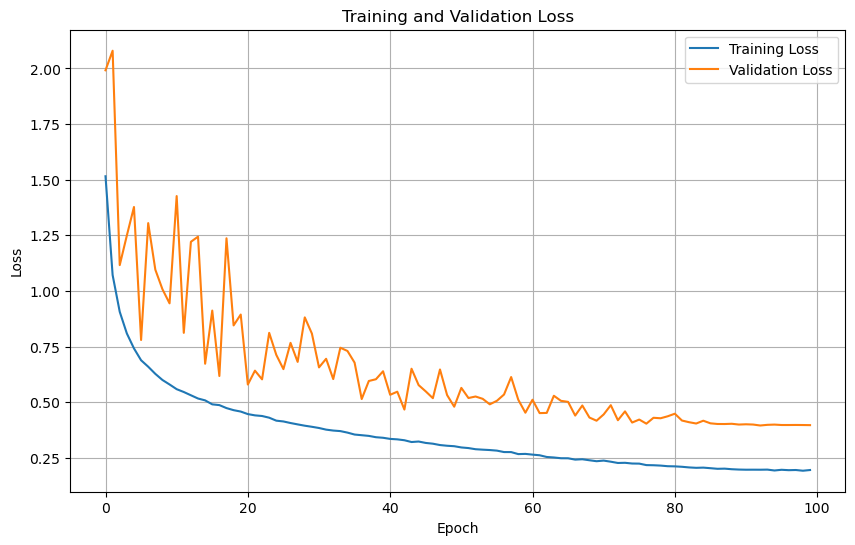

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


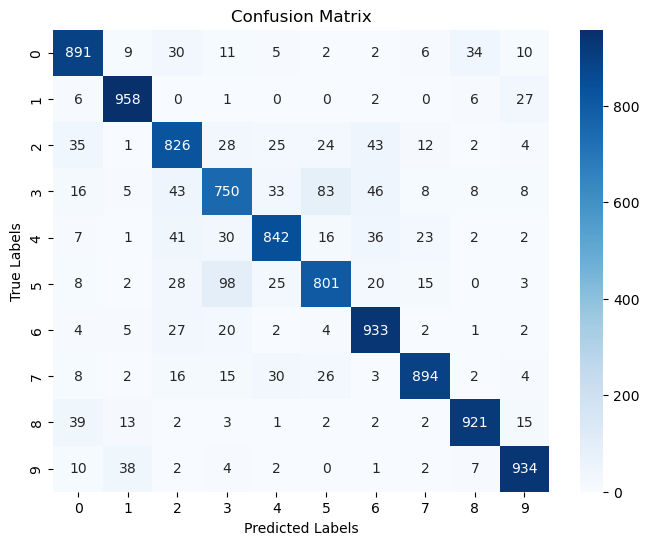

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1000
           1       0.93      0.96      0.94      1000
           2       0.81      0.83      0.82      1000
           3       0.78      0.75      0.77      1000
           4       0.87      0.84      0.86      1000
           5       0.84      0.80      0.82      1000
           6       0.86      0.93      0.89      1000
           7       0.93      0.89      0.91      1000
           8       0.94      0.92      0.93      1000
           9       0.93      0.93      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.87      0.88      0.87     10000
weighted avg       0.87      0.88      0.87     10000



In [22]:
# Add confusion matrix and classification report, and plot confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
predictions = model.predict(test_images)
pred_labels = np.argmax(predictions, axis=1)

# Compute confusion matrix
cm = confusion_matrix(test_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(test_labels, pred_labels))
